# Hewwo Welcome to Fake or Real Review Project

# Step 1: Look at the big picture

# Step 2: Get the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
import joblib
import random

In [3]:
reviews_df = pd.read_csv('fake reviews dataset.csv')

In [ ]:
reviews_df.head()

In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15155 entries, 0 to 15154
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  15155 non-null  object 
 1   rating    15155 non-null  float64
 2   label     15155 non-null  object 
 3   text_     15155 non-null  object 
dtypes: float64(1), object(3)
memory usage: 473.7+ KB


In [4]:
reviews_df.value_counts('label')

,count
label,
CG,20216
OR,20216


In [5]:
reviews_df.describe(include="all")


,category,rating,label,text_
count,40432,40432.000000,40432,40432
unique,10,NaN,2,40412
top,Kindle_Store_5,NaN,CG,My dog loves these and it has kept her occupie...
freq,4730,NaN,20216,2
mean,NaN,4.256579,NaN,NaN
std,NaN,1.144354,NaN,NaN
min,NaN,1.000000,NaN,NaN
25%,NaN,4.000000,NaN,NaN
50%,NaN,5.000000,NaN,NaN
75%,NaN,5.000000,NaN,NaN


In [6]:
reviews_df.value_counts("rating")

,count
rating,
5.0,24559
4.0,7965
3.0,3786
1.0,2155
2.0,1967


# clean the data

In [7]:
# drop rows that have the text missing
reviews_df.dropna(subset=['text_'], inplace=True)

#convert float64 ratings to integers
reviews_df["rating"] = reviews_df["rating"].astype(int)

In [8]:
from sklearn.preprocessing import LabelEncoder

# reviews_df.dropna(how="any") use this if eliminate any row that contains an usable value. i.e.
# This is commented out because we want to keep rows that have feature other than text missing. To handle these values we will
# use imputer rather than just deleting entire row.

# convert the labels of Computer Generated and Original to 0 and 1.

label_encoder = LabelEncoder()
label_encoder.fit(["CG","OR"])
reviews_df['label'] = label_encoder.transform(reviews_df['label'])

reviews_df.head()



,category,rating,label,text_
0,Home_and_Kitchen_5,5,0,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5,0,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5,0,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,0,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5,0,Very nice set. Good quality. We have had the s...


# Split data into training and test data

In [9]:
# creates a split object, that represents 1 split, with 20% of the data being used for testing and 80 for training.
# random_state could be any number, it just ensures that the split is reproducible,
# meaning that if you run the code multiple times, you will get the same split each time.
reviews_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# reviews_split makes sure there is similar or same percentage of training and test sets.
# i.e. training set wont have 90% CG labels while testing set only have 10% CG labels.
# train_index and test_index are two NumPy arrays of row indices
# we get the data frame for both sets by passing it into the locate function of our original dataframe
for train_index, test_index in reviews_split.split(reviews_df, reviews_df["label"]):
  training_set = reviews_df.loc[train_index]
  testing_set = reviews_df.loc[test_index]

# x and y train are used for supervised learning. Labels shown to the model
x_train = training_set.drop(columns = ["label"])
y_train = training_set["label"]

# x and y test used for evaluated the trained model on supervised learning. Labels are not shown to the model.
x_test = testing_set.drop(columns = ['label'])
y_test = testing_set["label"]

display(x_train.info(),y_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 32345 entries, 25582 to 33847
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  32345 non-null  object
 1   rating    32345 non-null  int64 
 2   text_     32345 non-null  object
dtypes: int64(1), object(2)
memory usage: 1010.8+ KB
<class 'pandas.core.series.Series'>
Index: 32345 entries, 25582 to 33847
Series name: label
Non-Null Count  Dtype
--------------  -----
32345 non-null  int64
dtypes: int64(1)
memory usage: 505.4 KB


None

None

In [24]:
y_test

,label
33059,1
19898,0
38225,1
29581,0
1079,0
...,...
35089,1
39139,0
39084,0
28164,0


# Step 4: Prepare the Data for Machine Learning algorithms

## Data preprocessing pipelines (transformations)

In [ ]:
#Use one-hot encodign to conver the category strings in the category column to numerical values that the model can underestand
#Use scaling to scale rating numerical
#Use TF-IDF vectorizer to convert the review text into numerical features that the model can understand
#convert ratings to integers.


# note: might use small LLM to embed values for the text feature instead of TF-IDF to see which one gives more accurate results.

In [10]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

rating_feature = ['rating']
category_feature = ['category']
text_feature = 'text_'

#imputer handles the transformation of features that are either null or nan.
rating_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())

])
# one-hot converts column category into multiple columns with names of all values in the data. e.g. is_car, is_phone, is_radio instead of Category. Value in said rows
# are either 0 or 1 representing yes or no.
# unknown = "ignore" means that it will set all unknown values of new instances to 0s across the board for all the columns.
category_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value = "missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_pipeline = Pipeline([
  # not needed since we used dropna for all of invalid text values earlier
  # ("imputer", SimpleImputer(strategy="constant", fill_value="missing"))

  #tf-idf converts a string feature to a row of numbers. Each between 0-1 and represent each word.
  # i.e. Each new column name is each word, instead of a single column named text
  ('tf-idf', TfidfVectorizer(stop_words="english", max_features=5000))

])

preprocessing = ColumnTransformer([
    ("ratings", rating_pipeline, rating_feature),
    ("categories", category_pipeline, category_feature),
    ("text", text_pipeline, text_feature)
])

In [ ]:
# Manual implementaion of one-hot encoder. Column Transformer actually does this automatically. Can delete this block, but i kept it
# for reference

# one-hot encoding for category feature
from sklearn.preprocessing import OneHotEncoder
# set sparse to False to get a dense array(numpy array object) instead of a sparse matrix
# handle_uknown will ignore any categories in the test set that were not seen in the training set and will not raise an error when evaluating categories that have not been seen.
category_encoder = OneHotEncoder(sparse_output=False, handle_unknown = 'ignore')

# creates sparse matrix of one-hot encoded values for the category column
category_1hot_columns = category_encoder.fit_transform(reviews_df[['category']])
category_1hot_columns


# creates a new dataframe with the one-hot encoded values and column names base on the original category names
category_1hot_df = pd.DataFrame(category_1hot_columns, columns=category_encoder.get_feature_names_out())

# add the new columns to the original dataframe
reviews_df = pd.concat([reviews_df, category_1hot_df], axis =1)
reviews_df.head()
# delete the original "category"  column since we now have the one-hot encoded columns
reviews_df.drop(columns = ['category'])




In [11]:
reviews_df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5,0,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5,0,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5,0,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,0,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5,0,Very nice set. Good quality. We have had the s...


# Step 5: Select a Model and Train it

## Baseline Model
we use the dummy model, because it is the minimum level intelligence that we need to beat to be considered useful



In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate


baseline_pipeline = Pipeline([
  ('prep', preprocessing),
  ('dummymodel', DummyClassifier(strategy="most_frequent"))
])

scoring = cross_validate(
  baseline_pipeline,
  x_train, y_train, scoring= ["accuracy", "precision", "recall", "average_precision"], cv = 5
)

scoring


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'fit_time': array([1.22086668, 1.25745368, 1.916394  , 1.28772569, 1.61990547]),
 'score_time': array([0.61673808, 0.62063146, 1.05940962, 0.60293221, 1.48586512]),
 'test_accuracy': array([0.49992271, 0.49992271, 0.49992271, 0.49992271, 0.49992271]),
 'test_precision': array([0.        , 0.        , 0.        , 0.49992271, 0.49992271]),
 'test_recall': array([0., 0., 0., 1., 1.]),
 'test_average_precision': array([0.50007729, 0.50007729, 0.50007729, 0.49992271, 0.49992271])}

## Inital Support Vector Machine

In [13]:
from sklearn.svm import SVC

fake_review_classifier = make_pipeline(preprocessing, SVC())
fake_review_classifier.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('ratings',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['rating']),
                                                 ('categories',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category']),
                                                 ('text',
                                                  Pipeline(steps=[('tf-idf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   stop_words='english'))]),
                                                  'text_')])),
                ('svc', SVC())])

## Cross validate to check scores of the initial SVM

In [14]:
SVM_scoring = cross_validate(
  baseline_pipeline,
  x_train, y_train, scoring= ["accuracy", "precision", "recall", "average_precision"], cv = 5
)
print('''
===============
Printing Scores
===============\n
      ''', SVM_scoring
      )

print('''
===============
Printing mean of average_precision
===============\n
      ''',SVM_scoring["test_average_precision"].mean()
      )



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Printing Scores

       {'fit_time': array([2.17206287, 1.24063253, 1.26718974, 1.30227995, 1.26466775]), 'score_time': array([0.78382063, 0.64939213, 0.62623096, 0.66080928, 0.56391287]), 'test_accuracy': array([0.49992271, 0.49992271, 0.49992271, 0.49992271, 0.49992271]), 'test_precision': array([0.        , 0.        , 0.        , 0.49992271, 0.49992271]), 'test_recall': array([0., 0., 0., 1., 1.]), 'test_average_precision': array([0.50007729, 0.50007729, 0.50007729, 0.49992271, 0.49992271])}

Printing mean of average_precision

       0.5000154583397743


# Step 6: Fine-tune the Model

In [ ]:
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

# Initialize the GridSearchCV (or RandomSearchCV if chosen) object
grid_search = GridSearchCV(estimator=fake_review_classifier, param_grid=param_grid, cv=5, scoring='average_precision', n_jobs=-1, verbose=3)

# Fit the grid(random) search to the data
grid_search.fit(x_train, y_train)

# Print the best parameters and the best score achieved during the grid search
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [26]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best cross-validation score: 0.9358440007115021


# PCA Pipeline to visualize model

In [16]:

data_visualization_pipeline = Pipeline([
    ('preprocessing', preprocessing), # This is the object that produced the table above
    ('pca', PCA(n_components=2))
])

# Perform PCA
x_train_pca = data_visualization_pipeline.fit_transform(x_train)

# Visualize weight of features in a dimensional space of 2.

In [17]:
# Pull out the PCA obeject.

pca_step = data_visualization_pipeline.named_steps['pca']

# GET NEW COLUMN NAMES
# Get new features that were made with preprocessing column transformer.
feature_names = data_visualization_pipeline.named_steps['preprocessing'].get_feature_names_out()


# create the loadings DataFrame : tells you exactly how much each of the original features (like Rating or the word "Excellent") contributed to the two new PCA axes.
# PC1 and PC2 because we chose n_components = 2, dimensional space of 2. PC1 = x axis and PC2 = y-axis. Each data point represents an instance i.e. (PC1,PC2)
# a high number in PC1 let, for example rating lets say has .90, means that rating has a strong influence on PC1(x-axis) to move in the right direction on the graph.
loadings_df = pd.DataFrame(
    pca_step.components_,
    columns=feature_names,
    index=['PC1', 'PC2']
)
# 4. Instead of just display(loadings_df), show the TOP 10 features because our text column is broken down into many many columns we cant just print it all out.
print("--- Top 10 Features for PC1 (X-axis) ---")
print(loadings_df.T['PC1'].sort_values(ascending=False).head(10))

print("\n--- Top 10 Features for PC2 (Y-axis) ---")
print(loadings_df.T['PC2'].sort_values(ascending=False).head(10))

display(loadings_df)

--- Top 10 Features for PC1 (X-axis) ---
ratings__rating                                      0.999510
categories__category_Kindle_Store_5                  0.013159
categories__category_Toys_and_Games_5                0.008024
text__love                                           0.007458
text__great                                          0.007225
categories__category_Tools_and_Home_Improvement_5    0.005247
categories__category_Sports_and_Outdoors_5           0.004956
text__loves                                          0.004415
text__perfect                                        0.003103
text__loved                                          0.002489
Name: PC1, dtype: float64

--- Top 10 Features for PC2 (Y-axis) ---
categories__category_Kindle_Store_5    0.810825
categories__category_Books_5           0.277834
text__book                             0.175536
text__read                             0.113232
text__story                            0.108616
text__characters               

,ratings__rating,categories__category_Books_5,categories__category_Clothing_Shoes_and_Jewelry_5,categories__category_Electronics_5,categories__category_Home_and_Kitchen_5,categories__category_Kindle_Store_5,categories__category_Movies_and_TV_5,categories__category_Pet_Supplies_5,categories__category_Sports_and_Outdoors_5,categories__category_Tools_and_Home_Improvement_5,...,text__yrs,text__zero,text__zip,text__zipper,text__zippers,text__zoe,text__zombie,text__zombies,text__zone,text__zoom
PC1,0.99951,-0.000118,-0.008203,-0.008915,-0.000639,0.013159,-0.009690,-0.003821,0.004956,0.005247,...,0.000027,-0.000306,-0.000022,-0.000116,-0.000027,-0.000009,-0.000009,-0.000008,0.000002,-0.000068
PC2,-0.01273,0.277834,-0.122689,-0.148459,-0.165078,0.810825,-0.037284,-0.210884,-0.145078,-0.143465,...,-0.000243,-0.000410,-0.000234,-0.001475,-0.000276,0.000429,0.000622,0.000610,0.000057,-0.000565


# Plot 2D representation of Model

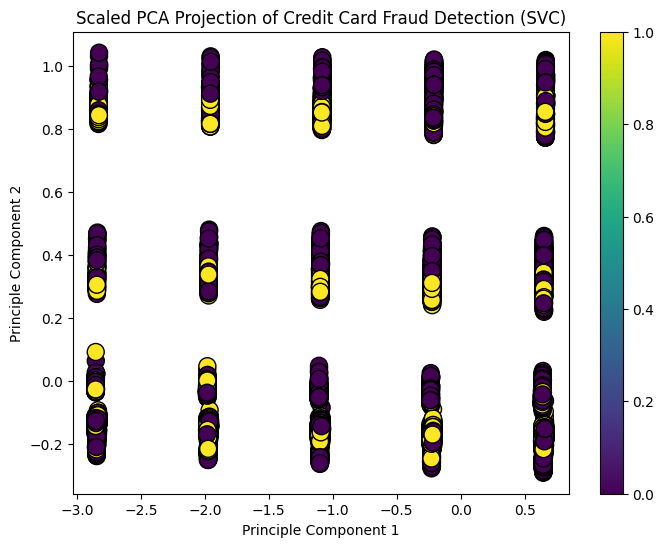

In [19]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train, cmap="viridis", edgecolor='k', s=150)
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.title("Scaled PCA Projection of Credit Card Fraud Detection (SVC)")
plt.colorbar(scatter)
plt.show()

Permuatation Importance to evaluate feature importance

In [20]:
results = permutation_importance(grid_search, x_test, y_test, n_repeats=3, random_state=42)
importances = results.importances_mean
print(importances)

[0.02711026 0.00870084 0.44057421]


Evaluate Final Model

In [22]:
# Hard predictions
y_test_pred = grid_search.predict(x_test)

# Probabilities (needed for ranking metrics)
#y_test_proba = grid_search.predict_proba(x_test)[:, 1]

display(y_test_pred)
#display(y_test_proba)

array([1, 0, 1, ..., 0, 0, 0])

Confusion Matrix

In [25]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
class_report = classification_report(y_test, y_test_pred, target_names=['Fake','Real'])
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Confusion Matrix:
 [[3528  516]
 [ 541 3502]]
Classification Report:
               precision    recall  f1-score   support

        Fake       0.87      0.87      0.87      4044
        Real       0.87      0.87      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



# Step 7: Present the Solution

# Step 8: Launch, Monitor, and Maintain the System

In [ ]:
#first Code block y